## pricessing the CMORIZED stable runs

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm as BM
import pandas as pd
import matplotlib as mpl
import matplotlib.ticker as mticker
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed


In [3]:
from scipy import stats

In [4]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 12
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 1.5
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

In [5]:
### Functions needed for the analysis

In [6]:
import matplotlib as m
from matplotlib.colors import BoundaryNorm as BM
import matplotlib.patches as mpatches

def plot_background(ax):
    ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
    # ax.set_global()
    # ax.add_feature(cfeature.LAND, color='lightgray')
    # ax.add_feature(cfeature.OCEAN, color='lightgray')
    gl = ax.gridlines(draw_labels=True,
                      linewidth=1, color='gray', alpha=0.01, linestyle='--')
    gl.top_labels = False
    # gl.left_labels = False
    # gl.bottom_labels = False
    gl.right_labels = False
    gl.xlines = False
    # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'k'}
    gl.ylabel_style = {'size': 10, 'color': 'k'}
    return ax


def plot_maps(x, y, z, titles, labels, cmap, levels, cbar_label = 'Precip', pval = [], nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False, cbar_orientation='vertical', hatch_type = 'insig'):
    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=True, subplot_kw={'projection':ccrs.Robinson(central_longitude=180)})
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        plot_background(ax)
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
        axlist[i].set_title(titles[i])
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            if hatch_type == 'insig':
                pval_plot = np.ma.masked_less_equal(pval[i], 0.05)
            elif hatch_type == 'sig':
                pval_plot = np.ma.masked_greater(pval[i], 0.05)
            axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='////', transform = ccrs.PlateCarree(central_longitude=0))
        axlist[i].set_title(titles[i], fontdict={'fontsize':12})
        axlist[i].text(0.1, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
        if add_patch:
            axlist[i].add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
        
    norm = BM(levels, 256, extend='both')
    fig.colorbar(m.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                orientation = cbar_orientation, shrink=0.4, aspect = 20, pad = 0.05, label = cbar_label)

In [7]:
from functions import preproc_funcs as funcs

In [8]:
from functions import xr_lowess

In [9]:
import glob

In [79]:
files_pic = sorted(glob.glob('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i1p1f1/Amon/rsus/gn/files/d20191115/*.nc'))
files_2030 = sorted(glob.glob('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i1p1f2/Amon/rsus/gn/files/d20250307/*.nc'))
files_2035 = sorted(glob.glob('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i2p1f2/Amon/rsus/gn/files/d20250307/*.nc'))
files_2040 = sorted(glob.glob('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i3p1f2/Amon/rsus/gn/files/d20250307/*.nc'))
files_2045 = sorted(glob.glob('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i4p1f2/Amon/rsus/gn/files/d20250307/*.nc'))
files_2050 = sorted(glob.glob('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i5p1f2/Amon/rsus/gn/files/d20250307/*.nc'))
files_2055 = sorted(glob.glob('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i6p1f2/Amon/rsus/gn/files/d20250307/*.nc'))
files_2060 = sorted(glob.glob('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i7p1f2/Amon/rsus/gn/files/d20250307/*.nc'))
files_2045

['/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i4p1f2/Amon/rsus/gn/files/d20250307/rsus_Amon_ACCESS-ESM1-5_esm-piControl_r1i4p1f2_gn_010101-020012.nc',
 '/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i4p1f2/Amon/rsus/gn/files/d20250307/rsus_Amon_ACCESS-ESM1-5_esm-piControl_r1i4p1f2_gn_020101-030012.nc',
 '/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i4p1f2/Amon/rsus/gn/files/d20250307/rsus_Amon_ACCESS-ESM1-5_esm-piControl_r1i4p1f2_gn_030101-040012.nc',
 '/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i4p1f2/Amon/rsus/gn/files/d20250307/rsus_Amon_ACCESS-ESM1-5_esm-piControl_r1i4p1f2_gn_040101-050012.nc',
 '/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i4p1f2/Amon/rsus/gn/files/d20250307/rsus_Amon_ACCESS-ESM1-5_esm-piControl_r1i4p1f2_gn_050101-060012.nc',
 '/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i4p1f2/Amon/rsus/gn/files

In [80]:
ds2030 = xc.open_mfdataset(files_2030)
# ds2035 = xc.open_mfdataset(files_2035)
# ds2040 = xc.open_mfdataset(files_2040)
ds2045 = xc.open_mfdataset(files_2045)
# ds2050 = xc.open_mfdataset(files_2050)
# ds2055 = xc.open_mfdataset(files_2055)
ds2060 = xc.open_mfdataset(files_2060)

In [81]:
# years = ['2030', '2035', '2040', '2045', '2050', '2055', '2060']
# years = ['2030', '2035', '2040', '2045', '2050', '2060']
years = ['2030', '2045', '2060']

In [82]:
# collection = dict(zip(years, [ds2030, ds2035, ds2040, ds2045, ds2050, ds2055, ds2060]))
# collection = dict(zip(years, [ds2030, ds2035, ds2040, ds2045, ds2050, ds2060]))
collection = dict(zip(years, [ds2030, ds2045, ds2060]))

In [83]:
# Function to process a single model and return the detrended NINO3.4 and precip anomalies
def process_model(model_identifier):
    try:
        # print(f"Processing model: {model_identifier}")
        # Load datasesiextents
        ds_stable = collection[model_identifier]
        # var = ds_stable['fld_s16i222'].resample(time='AS-JUN').mean('time').load()
        var = ds_stable.rsus.resample(time='AS-JUN').mean('time').load()
        # add custom time ranges
        stable_start_year = int(model_identifier)
        stable_end_year = int(stable_start_year) + len(var.time)
        var['time'] = xr.cftime_range(f'{stable_start_year}-01-01', f'{stable_end_year}-01-01', freq='1Y')
        #
        # precip = ds_precip['pr'] * 86400  # Convert kg/m²/s to mm/day

        # Calculate 3d values
        # var_anom = funcs.calc_anom(var, hist_access_r10.sel(time = slice('1960', '1990'))).resample(time = 'AS-JUN').mean('time').load()
        # siextents_trend = funcs.calc_trend3d(tos_anom.sel(time = slice('1980', '2014')), 'time')
        # siextents_trend_pval = funcs.calc_trend_pval3d(tos_anom.sel(time = slice('1980', '2014')), 'time')

        # calc timeseries values
        # weights = np.cos(np.deg2rad(siextents.lat))
        # gmst_anom = siextents_anom.weighted(weights).mean(('lat', 'lon'))
        # nino34_index = funcs.detrend1d_check(siextents_anom.sel(lat = slice(-5,5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), period=15)
        # wp_sst = siextents_anom.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon'))
        # ct_sst = siextents_anom.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))
        # so_sst = siextents_anom.sel(lat = slice(-65, -45), lon = slice(120, 290)).weighted(weights).mean(('lat', 'lon'))

        # print(f'Completed: {model_identifie}')
        return model_identifier, var
    except Exception as e:
        print(f"Error processing {model_identifier}: {e}")
        return model_identifier



In [47]:
import xesmf as xe

In [48]:
import multiprocessing as mp

In [49]:
ds_out = xe.util.cf_grid_2d(-0.75, 360, 1.5, -90, 90, 1.5)
ds_out

<xarray.Dataset> Size: 9kB
Dimensions:             (lon: 240, bound: 2, lat: 120)
Coordinates:
  * lon                 (lon) float64 2kB 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
  * lat                 (lat) float64 960B -89.25 -87.75 -86.25 ... 87.75 89.25
    latitude_longitude  float64 8B nan
Dimensions without coordinates: bound
Data variables:
    lon_bounds          (lon, bound) float64 4kB -0.75 0.75 0.75 ... 357.8 359.2
    lat_bounds          (lat, bound) float64 2kB -90.0 -88.5 -88.5 ... 88.5 90.0

In [84]:
# Run multiprocessing and gather results
res_arr = []
# with mp.Pool(processes=mp.cpu_count()) as pool:
with mp.Pool(processes=4) as pool:
    i = 0
    for res in pool.imap(process_model, years):
        res_arr.append(res)
        print(f'Completed {i+1}/{len(years)}', end='\r')
        i += 1



In [85]:
variants = []
ds_arr = []
for i in range(3):
    variants.append(res_arr[i][0])
    ds_arr.append(res_arr[i][1])

In [86]:
variants

['2030', '2045', '2060']

In [87]:
ds_arr

[<xarray.DataArray 'rsus' (time: 1001, lat: 145, lon: 192)> Size: 111MB
 array([[[100.444824, 100.444824, 100.444824, ..., 100.444824,
          100.444824, 100.444824],
         [104.63139 , 104.699425, 104.69774 , ..., 104.51349 ,
          104.51591 , 104.57469 ],
         [107.17141 , 107.207886, 107.360275, ..., 106.94835 ,
          106.945595, 107.07528 ],
         ...,
         [ 69.76099 ,  69.762405,  69.75463 , ...,  69.78204 ,
           69.70783 ,  69.74736 ],
         [ 68.50643 ,  68.6095  ,  68.5923  , ...,  68.51425 ,
           68.50676 ,  68.58923 ],
         [ 67.5692  ,  67.5692  ,  67.5692  , ...,  67.5692  ,
           67.5692  ,  67.5692  ]],
 
        [[105.094124, 105.094124, 105.094124, ..., 105.094124,
          105.094124, 105.094124],
         [106.53919 , 106.631004, 106.63737 , ..., 106.34109 ,
          106.394135, 106.46133 ],
         [106.438225, 106.49436 , 106.51041 , ..., 106.385925,
          106.43963 , 106.38953 ],
 ...
         [ 57.995697,  5

In [88]:
out = xr.concat([x.to_dataset(name='rsus') for x in ds_arr], dim=variants).rename(dict(concat_dim = 'model'))

In [89]:
regridder = xe.Regridder(out, ds_out, 'bilinear', periodic=True, ignore_degenerate=True)

In [90]:
out_regrid = regridder(out)
out_regrid

<xarray.Dataset> Size: 356MB
Dimensions:             (model: 3, time: 1031, lat: 120, lon: 240)
Coordinates:
  * time                (time) object 8kB 2030-12-31 00:00:00 ... 3060-12-31 ...
  * model               (model) object 24B '2030' '2045' '2060'
  * lon                 (lon) float64 2kB 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
    latitude_longitude  float64 8B nan
  * lat                 (lat) float64 960B -89.25 -87.75 -86.25 ... 87.75 89.25
Data variables:
    rsus                (model, time, lat, lon) float32 356MB 103.0 ... 46.44
Attributes:
    regrid_method:  bilinear

In [91]:
out_regrid.to_netcdf('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/access_stable_rsus.nc')
# out.to_netcdf('/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable_siextents_original.nc')

In [30]:
# out['siextents'].isel(model = 0).dropna('time').isel(time = slice(1, -1)).plot()

### analysing  the thetao and regional subsurface temperatures

In [10]:
# files_pic = sorted(glob.glob('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i1p1f1/Omon/thetao/gn/files/d20191115/*.nc'))
files_2030 = '/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i1p1f2/Omon/thetao/gn/files/d20250307/*.nc'
# files_2035 = sorted(glob.glob('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i2p1f2/Omon/thetao/gn/files/d20250307/*.nc'))
# files_2040 = sorted(glob.glob('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i3p1f2/Omon/thetao/gn/files/d20250307/*.nc'))
files_2045 = '/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i4p1f2/Omon/thetao/gn/files/d20250307/*.nc'
# files_2050 = sorted(glob.glob('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i5p1f2/Omon/thetao/gn/files/d20250307/*.nc'))
# files_2055 = sorted(glob.glob('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i6p1f2/Omon/thetao/gn/files/d20250307/*.nc'))
files_2060 = '/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i7p1f2/Omon/thetao/gn/files/d20250307/*.nc'
files_2045

'/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i4p1f2/Omon/thetao/gn/files/d20250307/*.nc'

In [49]:
ds2060 = xr.open_mfdataset(files_2060).thetao.sel(lev = slice(0, 2000)).resample(time = 'AS-JUN').mean('time')

In [50]:
# Assume your coordinate variables are named 'lat' and 'lon' and depend on (i, j)
lat = ds2060['latitude']  # shape: (i, j)
lon = ds2060['longitude']

# Define your region
# lat_min, lat_max = -80, -40
# lon_min, lon_max = 100, 300

# Build a mask for where lat/lon fall within the box
# custom_mask = ((lat >= lat_min) & (lat <= lat_max) &
#               (lon >= lon_min) & (lon <= lon_max))

# custom_mask = ((lat >= lat_min) & (lat <= lat_max))

In [51]:
# custom_mask.plot()

In [52]:
from dask.diagnostics import ProgressBar

In [53]:
ds2060['time'] = xr.cftime_range('2060-01-01', '3061-01-01', freq='1Y')

In [54]:
i = 0
while i < 1000:
    with  ProgressBar():
        val_loaded = ds2060.isel(time = slice(i, i+100)).mean(('time', 'i')).load()
        val_loaded.to_netcdf(f'/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/thetao_zonal/access_stable_2060_{i}_{i+100}_mean.nc')
        print(f'Completed {i} to {i + 100}', end='\r')
        i += 100

[########################################] | 100% Completed | 223.91 s
[########################################] | 100% Completed | 233.36 s
[########################################] | 100% Completed | 192.63 s
[########################################] | 100% Completed | 172.80 s
[########################################] | 100% Completed | 189.24 s
[########################################] | 100% Completed | 217.05 s
[########################################] | 100% Completed | 192.62 s
[########################################] | 100% Completed | 192.92 s
[########################################] | 100% Completed | 197.65 s
[########################################] | 100% Completed | 194.70 s


In [57]:
del ds2060, val_loaded

### analysing  the ekman velocity

In [10]:
# files_pic = sorted(glob.glob('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i1p1f1/Omon/wo/gn/files/d20191115/*.nc'))
files_2030 = '/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i1p1f2/Omon/wo/gn/files/d20250307/*.nc'
# files_2035 = sorted(glob.glob('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i2p1f2/Omon/wo/gn/files/d20250307/*.nc'))
# files_2040 = sorted(glob.glob('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i3p1f2/Omon/wo/gn/files/d20250307/*.nc'))
files_2045 = '/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i4p1f2/Omon/wo/gn/files/d20250307/*.nc'
# files_2050 = sorted(glob.glob('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i5p1f2/Omon/wo/gn/files/d20250307/*.nc'))
# files_2055 = sorted(glob.glob('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i6p1f2/Omon/wo/gn/files/d20250307/*.nc'))
files_2060 = '/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i7p1f2/Omon/wo/gn/files/d20250307/*.nc'
files_2045

'/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/esm-piControl/r1i4p1f2/Omon/wo/gn/files/d20250307/*.nc'

In [19]:
ds2030 = xr.open_mfdataset(files_2030).wo.sel(lev = slice(0, 100)).mean('lev').resample(time = 'AS-JUN').mean('time')

In [20]:
# Assume your coordinate variables are named 'lat' and 'lon' and depend on (i, j)
# lat = ds2045['latitude']  # shape: (i, j)
# lon = ds2045['longitude']

# Define your region
# lat_min, lat_max = -80, -40
# lon_min, lon_max = 100, 300

# Build a mask for where lat/lon fall within the box
# custom_mask = ((lat >= lat_min) & (lat <= lat_max) &
#               (lon >= lon_min) & (lon <= lon_max))

# custom_mask = ((lat >= lat_min) & (lat <= lat_max))

In [21]:
# custom_mask.plot()

In [22]:
from dask.diagnostics import ProgressBar

In [23]:
ds2030['time'] = xr.cftime_range('2030-01-01', '3031-01-01', freq='1Y')

In [24]:
# i = 0
# while i < 1000:
#     with  ProgressBar():
#         val_loaded = ds2060.isel(time = slice(i, i+100)).load()
#         val_loaded.to_netcdf(f'/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/thetao_zonal/access_stable_2060_{i}_{i+100}_mean.nc')
#         print(f'Completed {i} to {i + 100}', end='\r')
#         i += 100

In [25]:
with ProgressBar():
    val_loaded = ds2030.load()
    val_loaded.to_netcdf(f'/g/data/ob22/as8561/data/enso_trans_stable/sst_grad_res/access_stable/wo/access_stable_2030.nc')
    # print(f'Completed {i} to {i + 100}', end='\r')

[########################################] | 100% Completed | 43m 12s


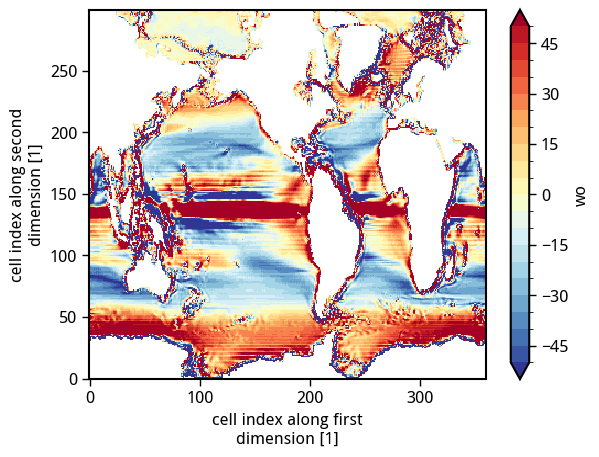

In [ ]:
## cm/day
# (val_loaded.isel(time = slice(0, 100)).mean('time')*8.64e6).plot(levels=np.linspace(-14, 14, 21), cmap='RdYlBu_r')

#m/year
(val_loaded.isel(time = slice(0, 100)).mean('time')*3.154e7).plot(levels=np.linspace(-50, 50, 21), cmap='RdYlBu_r')